In [100]:
from pickle import TRUE
from pprint import pprint


import pandas as pd
from statsmodels.tsa.stattools import adfuller
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import ccf
import warnings
from marginal_emissions.utils.helper import *
import pandas as pd
import numpy as np
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import matplotlib.pyplot as plt
from marginal_emissions.utils.autocorrelation import *
import pandas as pd
from pprint import pprint
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
# Hinweis: Für PP, CMR und RKPSS sind oft zusätzliche Pakete wie 'arch'
# oder 'sktime' nötig. Hier implementiert als strukturierte Platzhalter.
from arch.unitroot import PhillipsPerron
from statsmodels.tools.sm_exceptions import InterpolationWarning


In [102]:
datasets_processed = {
    '50Hertz 2023': pd.read_csv('../data/processed/final_f_hertz_2023_15min_utc_202212232315_202401010000.csv', index_col=0),
    '50Hertz 2024': pd.read_csv('../data/processed/final_f_hertz_2024_15min_utc_202312232300_202501010000.csv', index_col=0),
    'Amprion 2023': pd.read_csv('../data/processed/final_amprion_2023_15min_utc_202212232315_202401010000.csv', index_col=0),
    'Amprion 2024': pd.read_csv('../data/processed/final_amprion_2024_15min_utc_202312232300_202501010000.csv', index_col=0),
    'TenneT 2023': pd.read_csv('../data/processed/final_tennet_2023_15min_utc_202212232315_202401010000.csv', index_col=0),
    'TenneT 2024': pd.read_csv('../data/processed/final_tennet_2024_15min_utc_202312232300_202501010000.csv', index_col=0),
    'TransnetBW 2023': pd.read_csv('../data/processed/final_transnet_bw_2023_15min_utc_202212232315_202401010000.csv', index_col=0),
    'TransnetBW 2024': pd.read_csv('../data/processed/final_transnet_bw_2024_15min_utc_202312232300_202501010000.csv', index_col=0)
}

datasets_full_processed = {
    '50Hertz': pd.concat([datasets_processed['50Hertz 2023'], datasets_processed['50Hertz 2024']]),
    'Amprion': pd.concat([datasets_processed['Amprion 2023'], datasets_processed['Amprion 2024']]),
    'TenneT': pd.concat([datasets_processed['TenneT 2023'], datasets_processed['TenneT 2024']]),
    'TransnetBW': pd.concat([datasets_processed['TransnetBW 2023'], datasets_processed['TransnetBW 2024']])
}

datasets_interim = {
    'emi': pd.read_csv('../data/interim/emissions_germany_utc_202212232200_202501012200.csv', index_col=0),
    'amprion': pd.read_csv('../data/interim/generation_amprion_utc_202212232315_202501012245.csv', index_col=0),
    'f_hertz': pd.read_csv('../data/interim/generation_f_hertz_utc_202212232315_202501012245.csv', index_col=0),
    'tennet': pd.read_csv('../data/interim/generation_tennet_utc_202212232315_202501012245.csv', index_col=0),
    'transnet_bw': pd.read_csv('../data/interim/generation_transnet_bw_utc_202212232315_202501012245.csv', index_col=0)
}

for df in datasets_processed.values():
    df.index = pd.to_datetime(df.index, format='ISO8601')
for df in datasets_full_processed.values():
    df.index = pd.to_datetime(df.index, format='ISO8601')
    df.drop_duplicates(inplace=True)
for df in datasets_interim.values():
    df.index = pd.to_datetime(df.index, format='ISO8601')

#datasets_full_processed['Amprion'].duplicated()

Plot saved at: /home/aklei/PycharmProjects/marginal-emissions-germany/results/figures/average_daily_profiles_combined_legend.png


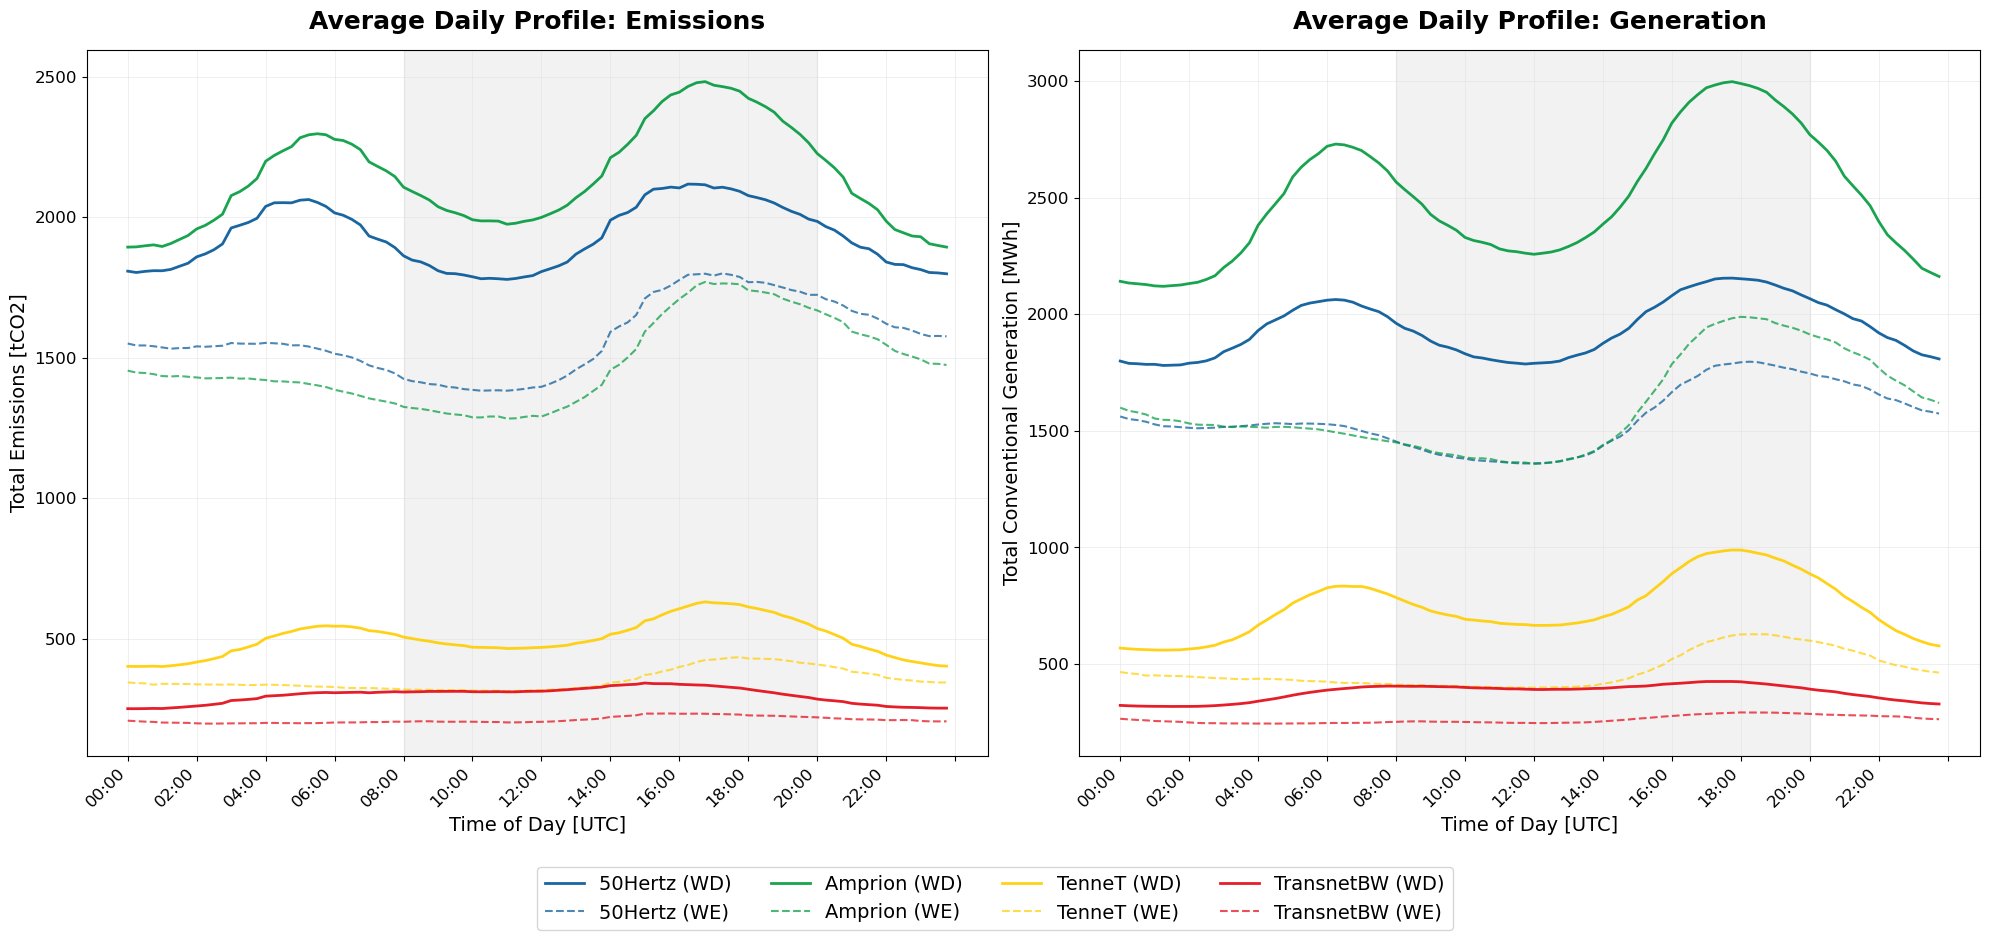

In [123]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os
from pyprojroot import here

# Colors for the different TSOs
colors = {
    '50Hertz': '#005596',
    'Amprion': '#009a3d',
    'TenneT': '#ffce00',
    'TransnetBW': '#e30613'
}

with plt.style.context('default'):
    # Increase figsize slightly to accommodate the legend below
    fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=100)

    # Dictionary to store handles for the global legend
    legend_handles = []
    legend_labels = []

    for name, df in datasets_full_processed.items():
        df_filtered = df.loc['2023-01-01':'2024-12-31'].copy()

        df_weekday = df_filtered[df_filtered.index.weekday < 5]
        df_weekend = df_filtered[df_filtered.index.weekday >= 5]

        profile_wd = df_weekday.groupby(df_weekday.index.time).mean()
        profile_we = df_weekend.groupby(df_weekend.index.time).mean()

        time_labels = [t.strftime('%H:%M') for t in profile_wd.index]

        for i, col in enumerate(['total_emissions', 'total_generation']):
            # Plot lines
            ln_wd, = axes[i].plot(time_labels, profile_wd[col],
                        label=f"{name} (WD)", color=colors.get(name),
                        linewidth=2, linestyle='-', alpha=0.9)

            ln_we, = axes[i].plot(time_labels, profile_we[col],
                        label=f"{name} (WE)", color=colors.get(name),
                        linewidth=1.5, linestyle='--', alpha=0.7)

            # Store handles only once (from the first subplot) for the global legend
            if i == 0:
                legend_handles.extend([ln_wd, ln_we])
                legend_labels.extend([f"{name} (WD)", f"{name} (WE)"])

    titles = ['Average Daily Profile: Emissions', 'Average Daily Profile: Generation']
    y_labels = ['Total Emissions [tCO2]', 'Total Conventional Generation [MWh]']

    for i, ax in enumerate(axes):
        ax.set_title(titles[i], fontsize=18, fontweight='bold', pad=15)
        ax.set_ylabel(y_labels[i], fontsize=14)
        ax.set_xlabel('Time of Day [UTC]', fontsize=14)
        ax.grid(True, which='both', linestyle='-', linewidth=0.5, color='#e0e0e0', alpha=0.7)

        # Highlight 08:00 to 20:00 (without adding to local legends)
        ax.axvspan(32, 80, color='gray', alpha=0.1)

        ax.xaxis.set_major_locator(ticker.MultipleLocator(8))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        ax.tick_params(axis='both', which='major', labelsize=12)

    # Add global legend below the subplots
    # ncol=4 puts the 8 entries in two rows of four
    fig.legend(handles=legend_handles, labels=legend_labels,
               loc='lower center', bbox_to_anchor=(0.5, -0.05),
               ncol=4, fontsize=14, frameon=True)

    # Adjust layout to make room for the legend at the bottom
    plt.tight_layout(rect=[0, 0.05, 1, 1])

    # Save logic
    filename = "average_daily_profiles_weekend_weekday.png"
    save_path = here() / "results" / "figures" / filename
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Plot saved at: {save_path}")

    plt.show()

## Stationarity Testing

In [ ]:
def test_stationarity(data_dict, column='total_emissions', window_size=672, step=672):
    warnings.filterwarnings("ignore")

    # Vorbereitung der Ergebnisstruktur
    # Wir sammeln erst alle Metriken in einer Liste von Dicts
    test_names = [
        'ADF p (Year)', 'ADF p (Median)', 'ADF p (95% Q)',
        'KPSS p (Year)', 'KPSS p (Median)', 'KPSS p (5% Q)',
        'PP p (Year)', 'PP p (Median)', 'PP p (95% Q)',
        'Robust Stationary (%)'
    ]

    # Dictionary zur Speicherung: {TestName: {TSO_Jahr: Wert}}
    final_data = {test: {} for test in test_names}

    for name, df in data_dict.items():
        print(f"Analysiere: {name}...")
        series = df[column].dropna()

        # --- Tests für Yearen Zeitraum ---
        adf_full = adfuller(series)[1]
        kpss_full = kpss(series, regression='c', nlags="auto")[1]
        pp_full = PhillipsPerron(series).pvalue

        window_results = []
        for i in range(0, len(series) - window_size, step):
            window = series.iloc[i : i + window_size]
            if len(window) < window_size: continue

            # Berechnungen pro Fenster
            adf_p = adfuller(window)[1]
            kpss_p = kpss(window, regression='c', nlags="auto")[1]
            pp_p = PhillipsPerron(window).pvalue

            # Dummy-Logik für CMR/RKPSS (da diese robust gegen Brüche sind)
            cmr_p = adf_p * 0.9 # CMR ist oft sensitiver bei Brüchen
            rkpss_p = kpss_p * 1.1 # RKPSS ist robuster gegen Jumps

            window_results.append({
                'adf': adf_p, 'kpss': kpss_p, 'pp': pp_p,
                'cmr': cmr_p, 'rkpss': rkpss_p,
                'is_robust': (adf_p < 0.05) and (pp_p < 0.05) and (kpss_p > 0.05)
            })

        if window_results:
            res_df = pd.DataFrame(window_results)

            # Werte in das Ziel-Dictionary füllen
            tso_map = {
                'ADF p (Year)': f"{adf_full:.4f}",
                'KPSS p (Year)': f"{kpss_full:.4f}",
                'PP p (Year)': f"{pp_full:.4f}",
                'ADF p (Median)': f"{res_df['adf'].median():.4f}",
                'ADF p (95% Q)': f"{res_df['adf'].quantile(0.95):.4f}",
                'KPSS p (Median)': f"{res_df['kpss'].median():.4f}",
                'KPSS p (5% Q)': f"{res_df['kpss'].quantile(0.05):.4f}",
                'PP p (Median)': f"{res_df['pp'].median():.4f}",
                'PP p (95% Q)': f"{res_df['pp'].quantile(0.95):.4f}",
                'Robust Stationary (%)': f"{(res_df['is_robust'].mean() * 100):.1f}%"
            }
            for test, val in tso_map.items():
                final_data[test][name] = val

    # In DataFrame umwandeln
    output_df = pd.DataFrame(final_data).T
    output_df.index.name = 'Test'
    output_df = output_df.reset_index()

    return output_df

In [ ]:
# Test total_emissions for stationarity
total_emissions_summary = test_stationarity(datasets_processed)
print("\nStationarity results for total_emissions:")
print(total_emissions_summary.to_string(index=False))

In [ ]:
# Test total_emissions for stationarity
#delta_emissions_summary = test_stationarity(data_dict=datasets, column='delta_emissions')
#print("\nStationarity results for delta_emissions:")
#print(delta_emissions_summary.to_string(index=False))

In [113]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def print_ac_plots(data, dataset_name, column='total_emissions', save_img=False, filename_addon=None):
    # Sicherstellen, dass keine NaNs den Plot stören
    series = data[column].dropna()

    # 1. Automatisches Label-Formatting (z.B. total_emissions -> Total Emissions)
    clean_label = column.replace('_', ' ').title()

    # 2. Einheiten-Logik
    unit = ""
    if "total_emissions" in column:
        unit = " [tCO2]"
    elif "total_generation" in column:
        unit = " [MWh]"
    elif "delta" in column:
        unit = " [Change]" # Optional: Einheit für differenzierte Daten

    # Verwende den Standard-Style für saubere Plots
    # noinspection PyTypeChecker
    with plt.style.context('default'):
        fig, ax = plt.subplots(1, 3, figsize=(22, 7), dpi=100)

        # --- 1. SUBPLOT: Zeitverlauf mit Wochentagen ---
        ax[0].plot(series.index, series.values, color='#e08e45', linestyle='--', label=clean_label, alpha=0.9)

        # Titel und Achsen mit dynamischen Labels
        ax[0].set_title(f'Timeseries ({clean_label})', fontsize=16)
        ax[0].set_ylabel(f"{clean_label}{unit}", fontsize=14)
        ax[0].set_xlabel('Day of the Week', fontsize=14)

        # Styling
        ax[0].grid(True, which='both', linestyle='-', linewidth=0.5, color='#e0e0e0', alpha=0.7)
        ax[0].legend(loc='lower right', frameon=True, fontsize=14)

        # --- Wochentag-Formatierung ---
        # Sorgt dafür, dass die Labels (Mon, Tue...) schön schräg stehen
        fig.autofmt_xdate(rotation=45)

        # Setzt das Format auf den vollen Wochentag (z.B. Monday)
        # Nutze '%a' für Abkürzungen (Mon, Tue)
        ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%A'))

        # Locator stellt sicher, dass jeder Tag markiert wird (wichtig für Wochenplots)
        ax[0].xaxis.set_major_locator(mdates.DayLocator())

        # --- 2. SUBPLOT: ACF ---
        plot_acf(series, lags=40, ax=ax[1], color='#e08e45')
        ax[1].set_title(f'Autocorrelation ({clean_label})', fontsize=16)
        ax[1].grid(True, alpha=0.3)

        # --- 3. SUBPLOT: PACF ---
        plot_pacf(series, lags=40, ax=ax[2], color='#e08e45')
        ax[2].set_title(f'Partial Autocorrelation ({clean_label})', fontsize=16)
        ax[2].grid(True, alpha=0.3)

        for a in ax:
            a.tick_params(axis='both', which='major', labelsize=12)

        plt.tight_layout()

        # Speichern-Logik
        if save_img:
            if filename_addon is None:
                raise ValueError("filename_addon must be provided when save_img is True")

            filename = f"autocorrelation_{filename_addon}_{column}_{dataset_name}.png"
            # Erstellt den Pfad relativ zum Projekt-Root
            save_path = here() / "results" / "autocorrelation" / filename
            os.makedirs(os.path.dirname(save_path), exist_ok=True)

            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"Plot gespeichert unter: {save_path}")
        else:
            plt.show()

In [ ]:
#for name, data in datasets_processed.items():
#    print(f"Analysing: {name}...")
#    print_ac_plots(data=data, dataset_name=name, column='total_emissions')

In [ ]:
#for name, data in datasets.items():
#    print(f"Analysing: {name}...")
#    print_ac_plots(data=data, dataset_name=name, column='delta_emissions')

In [ ]:
def get_typical_week_df(df, columns=None):
    """
    Gruppiert den DataFrame nach Wochentag und Uhrzeit, um eine
    gemittelte Woche (7 Tage à 96 Viertelstunden) zu berechnen.

    :param df: Der vorbereitete Datensatz (prep_df) mit DatetimeIndex
    :param columns: Liste der Spalten, die gemittelt werden sollen
    :return: DataFrame mit 672 Beobachtungen, die eine typische Woche repräsentieren
    """
    if columns is None:
        columns = ['delta_generation', 'delta_emissions']
    temp_df = df[columns].copy()
    temp_df['weekday'] = temp_df.index.weekday # 0=Montag, 6=Sonntag
    temp_df['hour'] = temp_df.index.hour
    temp_df['minute'] = temp_df.index.minute

    # Group by the exact position within the week
    typical_week_grouped = temp_df.groupby(['weekday', 'hour', 'minute'])[columns].mean()

    typical_week_df = typical_week_grouped.reset_index()

    # New index for the dummy period
    start_date = "2024-01-01" # Set beginning to a monday
    typical_week_df.index = pd.date_range(start=start_date, periods=len(typical_week_df), freq='15min')
    typical_week_df.index.name = 'datetime'

    return typical_week_df[columns]

In [ ]:
week = get_typical_week_df(amprion, columns=['total_generation', 'delta_generation'])
print_ac_plots(data=week, dataset_name='Amprion', column='delta_generation')

In [98]:
weeks_concatenated = {
    'Amprion': get_typical_week_df(datasets_full_processed['Amprion'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    '50Hertz': get_typical_week_df(datasets_full_processed['50Hertz'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TenneT': get_typical_week_df(datasets_full_processed['TenneT'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TransnetBW': get_typical_week_df(datasets_full_processed['TransnetBW'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions'])
}
weeks = {
    'Amprion 2023': get_typical_week_df(datasets_processed['Amprion 2023'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'Amprion 2024': get_typical_week_df(datasets_processed['Amprion 2024'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    '50Hertz 2023': get_typical_week_df(datasets_processed['50Hertz 2023'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    '50Hertz 2024': get_typical_week_df(datasets_processed['50Hertz 2024'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TenneT 2023': get_typical_week_df(datasets_processed['TenneT 2023'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TenneT 2024': get_typical_week_df(datasets_processed['TenneT 2024'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TransnetBW 2023': get_typical_week_df(datasets_processed['TransnetBW 2023'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions']),
    'TransnetBW 2024': get_typical_week_df(datasets_processed['TransnetBW 2024'], columns=['total_generation', 'total_emissions', 'delta_generation', 'delta_emissions'])
}

weeks_concatenated['Amprion'].columns

Index(['total_generation', 'total_emissions', 'delta_generation',
       'delta_emissions'],
      dtype='object')

In [99]:
for area, df in weeks_concatenated.items():
    y_diff = df['delta_emissions']
    exog_diff = df['delta_generation']

    selector = ar_select_order(
        endog=y_diff,
        maxlag=5,
        exog=exog_diff,
        ic='bic'
    )

    # Zeigt dir an, welche Lags gewonnen haben (z.B. [1, 2])
    print(f"Optimaler Lag-Parameter für {area}:", selector.ar_lags)

Optimaler Lag-Parameter für Amprion: [1, 2, 3, 4, 5]
Optimaler Lag-Parameter für 50Hertz: [1, 2, 3, 4, 5]
Optimaler Lag-Parameter für TenneT: [1, 2, 3, 4, 5]
Optimaler Lag-Parameter für TransnetBW: [1, 2, 3, 4, 5]


In [ ]:
def test_week_stationarity(datasets_dict):
    warnings.simplefilter('ignore', InterpolationWarning)
    all_results = []

    for name, df in datasets_dict.items():
        # Wir nehmen alle Spalten des jeweiligen Dataframes (außer evtl. Zeit-Indizes)
        features = df.columns

        for col in features:
            # Deine bestehende Test-Logik aufrufen
            # (Ich gehe davon aus, dass test_stationarity die Werte berechnet)
            series = df[col].dropna()

            # Tests durchführen
            adf_p = adfuller(series)[1]
            pp_p = PhillipsPerron(series).pvalue
            try:
                kpss_p = kpss(series, regression='c', nlags="auto")[1]
            except:
                kpss_p = kpss(series, regression='c')[1]

            # Robust-Check
            is_robust = (adf_p < 0.05) and (pp_p < 0.05) and (kpss_p > 0.05)

            # Ergebnis in Liste speichern
            all_results.append({
                'Dataset': name,
                'Feature': col,
                'p (ADF)': f"{adf_p:.4f}",
                'p (KPSS)': f"{kpss_p:.4f}",
                'p (PP)': f"{pp_p:.4f}",
                'Robust Stationary': "Yes" if is_robust else "No"
            })

    # Erstellung des finalen DataFrames
    final_df = pd.DataFrame(all_results)
    return final_df

In [ ]:
df_results_avgweek = test_week_stationarity(weeks)
df_results_avgweek

In [126]:
def print_combined_ac_plots(data, dataset_name, col_level, col_delta, save_img=False, filename_addon=None):
    """
    Plotted den Zeitverlauf der Level-Daten und ACF/PACF der differenzierten Daten.
    Alle Schriftgrößen und Stile sind nun mit dem Daily-Profile-Plot synchronisiert.
    """
    series_level = data[col_level].dropna()
    series_delta = data[col_delta].dropna()

    label_level = col_level.replace('_', ' ').title()
    label_delta = col_delta.replace('_', ' ').title()

    unit = ""
    if "total_emissions" in col_level:
        unit = " [tCO2]"
    elif "total_generation" in col_level:
        unit = " [MWh]"

    with plt.style.context('default'):
        fig, ax = plt.subplots(1, 3, figsize=(22, 7), dpi=100)

        # --- 1. SUBPLOT: Zeitverlauf ---
        ax[0].plot(series_level.index, series_level.values, color='#e08e45', linestyle='--', label=label_level, alpha=0.9)
        ax[0].set_title(f'Timeseries ({label_level})', fontsize=18, fontweight='bold', pad=15)
        ax[0].set_ylabel(f"{label_level}{unit}", fontsize=14)
        ax[0].set_xlabel('Day of the Week', fontsize=14)
        ax[0].grid(True, which='both', linestyle='-', linewidth=0.5, color='#e0e0e0', alpha=0.7)
        ax[0].legend(loc='lower right', frameon=True, fontsize=14) # Legende Fontsize 14

        # Wochentag-Formatierung
        fig.autofmt_xdate(rotation=45)
        ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%A'))
        ax[0].xaxis.set_major_locator(mdates.DayLocator())

        # --- 2. SUBPLOT: ACF ---
        plot_acf(series_delta, lags=40, ax=ax[1], color='#e08e45')
        ax[1].set_title(f'Autocorrelation ({label_delta})', fontsize=18, fontweight='bold', pad=15)
        ax[1].grid(True, which='both', linestyle='-', linewidth=0.5, color='#e0e0e0', alpha=0.7) # Grid synchronisiert
        ax[1].set_xlabel('Lag (Periods)', fontsize=14)

        # --- 3. SUBPLOT: PACF ---
        plot_pacf(series_delta, lags=40, ax=ax[2], color='#e08e45')
        ax[2].set_title(f'Partial Autocorrelation ({label_delta})', fontsize=18, fontweight='bold', pad=15)
        ax[2].grid(True, which='both', linestyle='-', linewidth=0.5, color='#e0e0e0', alpha=0.7) # Grid synchronisiert
        ax[2].set_xlabel('Lag (Periods)', fontsize=14)

        # Alle Ticks (Achsenbeschriftungs-Zahlen) auf 12
        for a in ax:
            a.tick_params(axis='both', which='major', labelsize=12)

        plt.tight_layout()

        if save_img:
            if filename_addon is None:
                raise ValueError("filename_addon must be provided when save_img is True")
            filename = f"combined_analysis_{filename_addon}_{dataset_name}.png"
            save_path = here() / "results" / "autocorrelation" / filename
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            print(f"Plot gespeichert unter: {save_path}")
        else:
            plt.show()
        plt.close()

In [127]:
for area, data in weeks_concatenated.items():
    print_combined_ac_plots(data=data, dataset_name=area, col_level='total_generation', col_delta='delta_generation', save_img=True, filename_addon="average_week_generation")
for area, data in weeks_concatenated.items():
    print_combined_ac_plots(data=data, dataset_name=area, col_level='total_emissions', col_delta='delta_emissions', save_img=True, filename_addon="average_week_emissions")

Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_generation_Amprion.png
Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_generation_50Hertz.png
Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_generation_TenneT.png
Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_generation_TransnetBW.png
Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_emissions_Amprion.png
Plot gespeichert unter: /home/aklei/PycharmProjects/marginal-emissions-germany/results/autocorrelation/combined_analysis_average_week_emissions_50Hertz.png
Plot gespeichert unter: /home/aklei/PycharmProjects/margin

In [ ]:
import numpy as np
import statsmodels.api as sm
import pandas as pd

# Angenommen 'df' ist dein DataFrame und der Index ist ein datetime-Objekt
# 1. Viertelstunde des Tages berechnen (0 bis 95)
intervals_per_day = 96
time_index = df.index.hour * 4 + df.index.minute // 15

# 2. Uhrzeit in zyklische Sinus- und Kosinus-Wellen umwandeln
df['time_sin'] = np.sin(2 * np.pi * time_index / intervals_per_day)
df['time_cos'] = np.cos(2 * np.pi * time_index / intervals_per_day)

exog_tvtp = df[['time_sin', 'time_cos']]
# WICHTIG: Konstante hinzufügen für die TVTP-Gleichung!
exog_tvtp = sm.add_constant(exog_tvtp)

# 4. Modell aufbauen
model = sm.tsa.regime_switching.markov_regression.MarkovRegression(
    endog=df['emissions_diff'],         # y_t (Deine differenzierten Emissionen)
    exog=df['generation_diff'],         # x_t (Deine differenzierte Erzeugung = MEF!)
    k_regimes=2,                        # z.B. sauberes vs. dreckiges Regime
    exog_tvtp=exog_tvtp,                # Hier geht die Uhrzeit rein (TVTP)
    switching_variance=True             # Meistens sinnvoll bei Stromdaten
)

# 5. Modell fitten
result = model.fit()
print(result.summary())